Fitted parameters: k_pol =  0.978 [pN/nm], D_pol =  4039.661 [nm2/s]


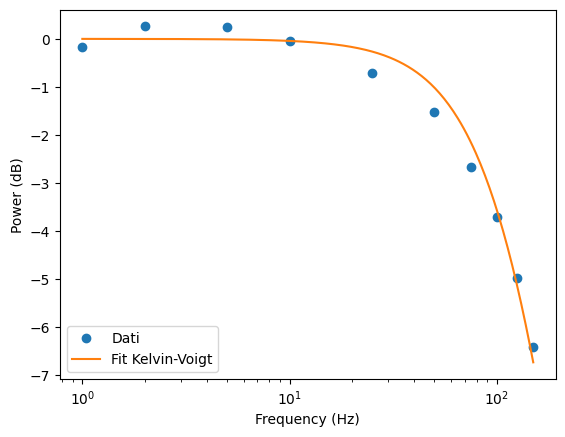

In [3]:
# fitting DB power intensity to KELVIN VOIGT eq to get Diffusion coeff

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

frequencies = np.array([1, 2, 5, 10, 25, 50, 75, 100, 125, 150])
y_values = np.array([
    -0.1625511778654903, 0.2611017452924966, 0.251787925632402, 
    -0.04397791983566283, -0.7047976514765943, -1.515531322186259,
    -2.665479734807541, -3.714722847729757, -4.976423688217507,
    -6.424312418688706
])

# plt.plot(frequencies, y_values, 'o', label='Data Points')
# plt.xscale("log")
# plt.ylabel("Power (dB)")
# plt.xlabel("frequency (Hz)")
# plt.show() 

kT = 4.11 

def Kelvin_Voigt(f, k_pol, D_pol):
    I =  10* np.log(1/(1+ ((2*np.pi*f *kT)/(k_pol*D_pol))**2))
    return I 

params, _ = curve_fit(Kelvin_Voigt, frequencies, y_values, p0=[1, 3000], )
k_fit, D_fit = params
print (f"Fitted parameters: k_pol = {k_fit: .3f} [pN/nm], D_pol = {D_fit: .3f} [nm2/s]")

f_fit = np.logspace(np.log10(min(frequencies)), np.log10(max(frequencies)), 300)
y_model = Kelvin_Voigt(f_fit, *params)

plt.semilogx(frequencies, y_values, 'o', label='Dati')
plt.semilogx(f_fit, y_model, '-', label='Fit Kelvin-Voigt')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.legend()
plt.show()


In [8]:
# recover k_pol from theory e chekc the result 

# form the papar k_wlc: elasticity constant
lc , lp, F = 150, 0.58, 12
k_th=  4/lc * np.sqrt(lp/kT) * F**(3/2)

print(f"Elasticity constant k from theory: {k_th: .3f} [pN/nm]")

# k as dFdx from wlc F fefinition
# Rafa pensa che k dipenda piu dal rapporto estensione/estensione massima che nel paper method non è considerata 
x = 100 # estensione della proteina durante analisi vd pic 
k = kT/lp * (1/2 *(1- x/lc)**-3 *(1/lc) + 1/lc)

print(f"Elasticity constant k from dFdx: {k: .3f} [pN/nm]")


Elasticity constant k from theory:  0.416 [pN/nm]
Elasticity constant k from dFdx:  0.685 [pN/nm]
